# Student's t Distribution

The **t distribution** arises when estimating the mean of a normally distributed population from a small sample when the population variance is unknown. It has heavier tails than the Normal — the uncertainty about σ adds extra variability — but converges to N(0,1) as degrees of freedom increase.

| Property | Value |
|---|---|
| **Parameter** | ν (degrees of freedom, ν > 0) |
| **Support** | (−∞, +∞) |
| **PDF** | f(x) = Γ((ν+1)/2) / (√(νπ) Γ(ν/2)) · (1 + x²/ν)^(−(ν+1)/2) |
| **Mean** | 0 (undefined for ν=1) |
| **Variance** | ν/(ν−2) for ν > 2; undefined for ν ≤ 2 |
| **Skewness** | 0 (symmetric) |
| **Kurtosis** | 6/(ν−4) + 3 for ν > 4 (heavy tails) |
| **Special cases** | ν=1 → Cauchy; ν→∞ → N(0,1) |
| **Primary use** | t-tests, confidence intervals when σ is unknown |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

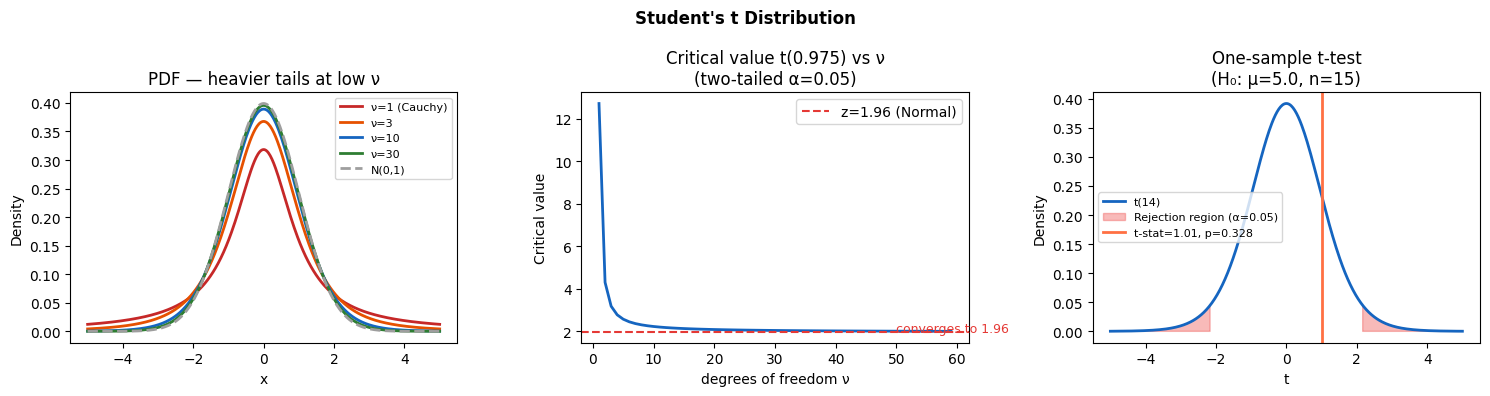

Sample: n=15, x̄=5.52, s=1.99
t-statistic=1.014, df=14, p-value=0.3277
Critical value t(0.975, df=14) = 2.145


In [2]:
x = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Student's t Distribution", fontsize=12, fontweight='bold')

# PDF — varying df
for df, color, label in [(1,  '#C62828', 'ν=1 (Cauchy)'),
                          (3,  '#E65100', 'ν=3'),
                          (10, '#1565C0', 'ν=10'),
                          (30, '#2E7D32', 'ν=30')]:
    axes[0].plot(x, stats.t(df).pdf(x), color=color, linewidth=2, label=label)
axes[0].plot(x, stats.norm(0,1).pdf(x), color='#9E9E9E', linewidth=2,
             linestyle='--', label='N(0,1)')
axes[0].set_title('PDF — heavier tails at low ν')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Critical values vs df (two-tailed α=0.05)
dfs = np.arange(1, 60)
t_crit = [stats.t(df).ppf(0.975) for df in dfs]
axes[1].plot(dfs, t_crit, color='#1565C0', linewidth=2)
axes[1].axhline(stats.norm.ppf(0.975), color='#E53935', linewidth=1.5,
                linestyle='--', label=f'z=1.96 (Normal)')
axes[1].set_title('Critical value t(0.975) vs ν\n(two-tailed α=0.05)')
axes[1].set_xlabel('degrees of freedom ν')
axes[1].set_ylabel('Critical value')
axes[1].legend()
axes[1].annotate('converges to 1.96', xy=(50, 1.97), fontsize=9, color='#E53935')

# t-test demonstration
np.random.seed(42)
n = 15
sample = np.random.normal(loc=5.5, scale=2, size=n)  # true mean = 5.5
null_mu = 5.0
t_stat, p_val = stats.ttest_1samp(sample, null_mu)
df_t = n - 1
t_range = np.linspace(-5, 5, 400)
axes[2].plot(t_range, stats.t(df_t).pdf(t_range), color='#1565C0', linewidth=2,
             label=f't({df_t})')
t_crit_val = stats.t(df_t).ppf(0.975)
axes[2].fill_between(t_range, stats.t(df_t).pdf(t_range),
                     where=(np.abs(t_range) >= t_crit_val),
                     color='#EF5350', alpha=0.4, label=f'Rejection region (α=0.05)')
axes[2].axvline(t_stat, color='#FF7043', linewidth=2,
                label=f't-stat={t_stat:.2f}, p={p_val:.3f}')
axes[2].set_title(f'One-sample t-test\n(H₀: μ={null_mu}, n={n})')
axes[2].set_xlabel('t'); axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Sample: n={n}, x̄={sample.mean():.2f}, s={sample.std(ddof=1):.2f}")
print(f"t-statistic={t_stat:.3f}, df={df_t}, p-value={p_val:.4f}")
print(f"Critical value t(0.975, df={df_t}) = {t_crit_val:.3f}")

## Key Takeaways

| | |
|---|---|
| **ν=1** | Reduces to Cauchy — no mean, very heavy tails |
| **ν→∞** | Converges to N(0,1) — practically Normal at ν≥30 |
| **Heavier tails** | Wider confidence intervals than z-based — accounts for unknown σ |
| **t-test** | T = (x̄ − μ₀)/(s/√n) ~ t(n−1) under H₀ |
| **Two-sample t-test** | Compares means of two groups; df from Welch's formula if variances differ |
| **Practical rule** | Use t (not z) whenever σ is unknown, regardless of sample size |
| **Critical values** | t(0.975, df=10)=2.23; t(0.975, df=30)=2.04; t(0.975, ∞)=1.96 |